In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('base_segundo_encontro.csv', encoding='latin', sep=';')
df

,tempo_conversa_min,risadas,pontos_comuns,nivel_timidez,mensagens_antes,iniciativa_conversa,local_encontro,momento_da_vida,segundo_encontro
0,112,16,6,0,45,8,Restaurante,Estressado,Sim
1,102,13,2,10,41,6,Bar,Estável,Sim
2,24,8,2,3,16,9,Café,Estável,Sim
3,116,7,4,0,8,4,Bar,Estressado,Sim
4,81,1,2,5,5,7,Parque,Estável,Não
...,...,...,...,...,...,...,...,...,...
995,129,19,6,0,25,8,Bar,Estável,Sim
996,68,17,5,6,12,3,Restaurante,Estável,Sim
997,137,5,3,7,7,7,Parque,Cansado,Sim
998,123,10,1,10,27,8,Bar,Estressado,Não


In [141]:
tempo_conversa = int(input('Duração do encontro >> '))
risada = int(input('Risadas >> '))
comuns = int(input('Pontos em comum >> '))
timidez = int(input('Timidez >> '))
msg_antes = int(input('Mensagens antes >> '))
iniciativa = int(input('Iniciativa (0-10) >> '))
local = input('Local do encontro >> ')
momento = input('Momento da vida >> ')

x = [tempo_conversa, risada, comuns, timidez, msg_antes, iniciativa, local, momento]
linha = pd.DataFrame([{"tempo_conversa_min": x[0], "risadas": x[1], "pontos_comuns": x[2], "nivel_timidez": x[3], "mensagens_antes": x[4], "iniciativa_conversa": x[5], "local_encontro": x[6], "momento_da_vida": x[7]}])

In [187]:
tempo_conversa = int(input('Duração do encontro >> '))
risada = int(input('Risadas >> '))
comuns = int(input('Pontos em comum >> '))
timidez = int(input('Timidez >> '))
msg_antes = int(input('Mensagens antes >> '))
iniciativa = int(input('Iniciativa (0-10) >> '))
local = input('Local do encontro >> ')
momento = input('Momento da vida >> ')

x = [tempo_conversa, risada, comuns, timidez, msg_antes, iniciativa, local, momento]
linha_nova = pd.DataFrame([{"tempo_conversa_min": x[0], "risadas": x[1], "pontos_comuns": x[2], "nivel_timidez": x[3], "mensagens_antes": x[4], "iniciativa_conversa": x[5], "local_encontro": x[6], "momento_da_vida": x[7]}])
linha = pd.concat([linha, linha_nova], ignore_index=True)

In [188]:
linha

,tempo_conversa_min,risadas,pontos_comuns,nivel_timidez,mensagens_antes,iniciativa_conversa,local_encontro,momento_da_vida
0,0,0,0,0,0,0,Bar,Cansado
1,120,10,5,20,30,10,Restaurante,Estressado
2,0,0,0,0,0,0,Parque,Estável
3,1,1,1,1,1,1,Café,Estável
4,112,16,6,0,45,8,Restaurante,Estressado
5,81,1,2,5,5,7,Parque,Estável
6,0,0,0,0,1,0,Bar,Cansado
7,0,0,0,10,0,0,Bar,Estável


In [189]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

x_enc = df.iloc[:, 0:8].values
y_enc = df.iloc[:, 8].values
linha_enc = linha.iloc[:, :].values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y_enc)

onehotencoder_enc = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [6,7])], remainder='passthrough')
onehotencoder_enc2 = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [6,7])], remainder='passthrough')
x_enc = onehotencoder_enc.fit_transform(x_enc)
linha_enc = onehotencoder_enc2.fit_transform(linha_enc)

In [190]:
from sklearn.preprocessing import StandardScaler
scaler_enc = StandardScaler()
x_enc = scaler_enc.fit_transform(x_enc)
linha_enc = scaler_enc.fit_transform(linha_enc)

In [191]:
from sklearn.model_selection import train_test_split

x_enc_treino, x_enc_teste, y_enc_treino, y_enc_teste = train_test_split(x_enc, y_enc, test_size=0.2, random_state=42)
x_enc_treino.shape, x_enc_teste.shape

((800, 13), (201, 13))

In [192]:
from sklearn.svm import SVC

lista = ['rbf', 'sigmoid', 'linear', 'poly']
svm_enc = SVC(kernel='rbf', C = 2)
svm_enc.fit(x_enc_treino, y_enc_treino)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [194]:
for i in lista:
    for j in range(1,10):
        svm_enc = SVC(kernel=i, C=j)
        svm_enc.fit(x_enc_treino, y_enc_treino)
        previsao = svm_enc.predict(linha_enc)
        print("Classe prevista:", previsao)

Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 1 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 1 0 1 1 1 0 0]
Classe prevista: [0 

In [193]:
previsao = svm_enc.predict(linha_enc)
print("Classe prevista:", previsao)

Classe prevista: [0 1 0 1 1 1 0 0]


0.9552238805970149

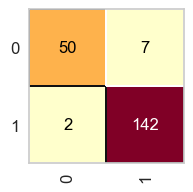

In [169]:
from yellowbrick.classifier import ConfusionMatrix
plt.figure(figsize=(2, 2))
cm = ConfusionMatrix(svm_enc, force_model=True)
cm.fit(x_enc_treino, y_enc_treino)
cm.score(x_enc_teste, y_enc_teste)

In [ ]:
x = df.drop("segundo_encontro", axis=1)
y = df{}